In [2]:
# ==========================================
# IPL END-TO-END ANALYTICS
# Author: Mamidala Bhanu Prasad
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option('display.max_columns', None)

# Display more rows
pd.set_option('display.max_rows', 100)

In [3]:
from google.colab import files

uploaded = files.upload()

Saving teams_data.csv to teams_data.csv


In [5]:
from google.colab import files

uploaded = files.upload()

Saving ipl_matches_data.csv to ipl_matches_data.csv


In [7]:
from google.colab import files

uploaded = files.upload()

Saving ball_by_ball_data.csv to ball_by_ball_data.csv


In [11]:
from google.colab import files

uploaded = files.upload()

Saving players_data_updated.csv to players_data_updated.csv


In [13]:
matches = pd.read_csv("ipl_matches_data.csv")

balls = pd.read_csv("ball_by_ball_data.csv")

teams = pd.read_csv("teams_data.csv")

In [15]:
players = pd.read_csv("players_data_updated.csv", encoding='latin1')

In [16]:
print("Matches:", matches.shape)

print("Ball by Ball:", balls.shape)

print("Players:", players.shape)

print("Teams:", teams.shape)

Matches: (1169, 24)
Ball by Ball: (278205, 30)
Players: (772, 8)
Teams: (16, 4)


In [17]:
matches.head()

,match_id,season_id,balls_per_over,city,match_date,event_name,match_number,gender,match_type,format,overs,season,team_type,venue,toss_winner,team1,team2,toss_decision,match_winner,win_by_runs,win_by_wickets,player_of_match,result,stage
0,335982,2008,6,Bangalore,18-04-2008,Indian Premier League,1.0,male,T20,T20,20,2008,club,M Chinnaswamy Stadium,Royal Challengers Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,field,Kolkata Knight Riders,140.0,NaN,46.0,win,NaN
1,1082591,2017,6,Hyderabad,05-04-2017,Indian Premier League,1.0,male,T20,T20,20,2017,club,"Rajiv Gandhi International Stadium, Uppal",Royal Challengers Bangalore,Sunrisers Hyderabad,Royal Challengers Bangalore,field,Sunrisers Hyderabad,35.0,NaN,15.0,win,NaN
2,1082592,2017,6,Pune,06-04-2017,Indian Premier League,2.0,male,T20,T20,20,2017,club,Maharashtra Cricket Association Stadium,Rising Pune Supergiant,Rising Pune Supergiant,Mumbai Indians,field,Rising Pune Supergiant,NaN,7.0,36.0,win,NaN
3,1082593,2017,6,Rajkot,07-04-2017,Indian Premier League,3.0,male,T20,T20,20,2017,club,Saurashtra Cricket Association Stadium,Kolkata Knight Riders,Gujarat Lions,Kolkata Knight Riders,field,Kolkata Knight Riders,NaN,10.0,57.0,win,NaN
4,1082594,2017,6,Indore,08-04-2017,Indian Premier League,4.0,male,T20,T20,20,2017,club,Holkar Cricket Stadium,Punjab Kings,Punjab Kings,Rising Pune Supergiant,field,Punjab Kings,NaN,6.0,71.0,win,NaN


In [18]:
balls.head()

,season_id,match_id,batter,bowler,non_striker,team_batting,team_bowling,over_number,ball_number,batter_runs,extras,total_runs,batsman_type,bowler_type,player_out,fielders_involved,is_wicket,is_wide_ball,is_no_ball,is_leg_bye,is_bye,is_penalty,wide_ball_runs,no_ball_runs,leg_bye_runs,bye_runs,penalty_runs,wicket_kind,is_super_over,innings
0,2008,335982,SC Ganguly,P Kumar,BB McCullum,Kolkata Knight Riders,Royal Challengers Bangalore,0,0,0,1,1,Left hand Bat,Right arm Medium,NaN,NaN,False,False,False,True,False,False,0,0,1,0,0,NaN,False,1
1,2008,335982,BB McCullum,P Kumar,SC Ganguly,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,0,0,0,Right hand Bat,Right arm Medium,NaN,NaN,False,False,False,False,False,False,0,0,0,0,0,NaN,False,1
2,2008,335982,BB McCullum,P Kumar,SC Ganguly,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,0,1,1,Right hand Bat,Right arm Medium,NaN,NaN,False,True,False,False,False,False,1,0,0,0,0,NaN,False,1
3,2008,335982,BB McCullum,P Kumar,SC Ganguly,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,0,0,0,Right hand Bat,Right arm Medium,NaN,NaN,False,False,False,False,False,False,0,0,0,0,0,NaN,False,1
4,2008,335982,BB McCullum,P Kumar,SC Ganguly,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,0,0,0,Right hand Bat,Right arm Medium,NaN,NaN,False,False,False,False,False,False,0,0,0,0,0,NaN,False,1


In [19]:
players.head()

,player_id,player_name,bat_style,bowl_style,field_pos,player_full_name,player_name2,player_image
0,6730,Mohsin Khan,Left hand Bat,Left arm Medium fast,NaN,Mohsin Khan,Mohsin Khan,NaN
1,22,Rashid Khan,Right hand Bat,Legbreak Googly,,Rashid Khan Arman,Rashid Khan,https://www.espncricinfo.com/cricketers/rashid...
2,590,K Rabada,Left hand Bat,Right arm Fast,,Kagiso Rabada,Kagiso Rabada,https://ipl-stats-sports-mechanic.s3.ap-south-...
3,1424,SN Khan,Right hand Bat,Legbreak,,Sarfaraz Naushad Khan,Sarfaraz Naushad,NaN
4,963,MN Samuels,Right hand Bat,Right arm Offbreak,,Marlon Nathaniel Samuels,Marlon Nathaniel,NaN


In [20]:
teams.head()

,team_id,team_name,team_name_short,image_url
0,1,Royal Challengers Bangalore,RCB,https://documents.iplt20.com/ipl/RCB/Logos/Log...
1,2,Sunrisers Hyderabad,SRH,https://documents.iplt20.com/ipl/SRH/Logos/Log...
2,3,Mumbai Indians,MI,https://documents.iplt20.com/ipl/MI/Logos/Logo...
3,4,Rising Pune Supergiant,RPS,https://ipl-stats-sports-mechanic.s3.ap-south-...
4,5,Gujarat Lions,GL,https://ipl-stats-sports-mechanic.s3.ap-south-...


In [21]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1169 entries, 0 to 1168
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   match_id         1169 non-null   int64  
 1   season_id        1169 non-null   int64  
 2   balls_per_over   1169 non-null   int64  
 3   city             1118 non-null   object 
 4   match_date       1169 non-null   object 
 5   event_name       1169 non-null   object 
 6   match_number     1099 non-null   float64
 7   gender           1169 non-null   object 
 8   match_type       1169 non-null   object 
 9   format           1169 non-null   object 
 10  overs            1169 non-null   int64  
 11  season           1169 non-null   object 
 12  team_type        1169 non-null   object 
 13  venue            1169 non-null   object 
 14  toss_winner      1168 non-null   object 
 15  team1            1169 non-null   object 
 16  team2            1169 non-null   object 
 17  toss_decision 

In [22]:
balls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278205 entries, 0 to 278204
Data columns (total 30 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   season_id          278205 non-null  int64 
 1   match_id           278205 non-null  int64 
 2   batter             278205 non-null  object
 3   bowler             278205 non-null  object
 4   non_striker        278205 non-null  object
 5   team_batting       278205 non-null  object
 6   team_bowling       278205 non-null  object
 7   over_number        278205 non-null  int64 
 8   ball_number        278205 non-null  int64 
 9   batter_runs        278205 non-null  int64 
 10  extras             278205 non-null  int64 
 11  total_runs         278205 non-null  int64 
 12  batsman_type       278205 non-null  object
 13  bowler_type        278205 non-null  object
 14  player_out         13823 non-null   object
 15  fielders_involved  13823 non-null   object
 16  is_wicket          2

In [23]:
players.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 772 entries, 0 to 771
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   player_id         772 non-null    int64 
 1   player_name       772 non-null    object
 2   bat_style         772 non-null    object
 3   bowl_style        759 non-null    object
 4   field_pos         707 non-null    object
 5   player_full_name  772 non-null    object
 6   player_name2      772 non-null    object
 7   player_image      134 non-null    object
dtypes: int64(1), object(7)
memory usage: 48.4+ KB


In [24]:
teams.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   team_id          16 non-null     int64 
 1   team_name        16 non-null     object
 2   team_name_short  16 non-null     object
 3   image_url        16 non-null     object
dtypes: int64(1), object(3)
memory usage: 644.0+ bytes


In [25]:
matches.isnull().sum()

,0
match_id,0
season_id,0
balls_per_over,0
city,51
match_date,0
event_name,0
match_number,70
gender,0
match_type,0
format,0


In [26]:
balls.isnull().sum()

,0
season_id,0
match_id,0
batter,0
bowler,0
non_striker,0
team_batting,0
team_bowling,0
over_number,0
ball_number,0
batter_runs,0


In [27]:
players.isnull().sum()

,0
player_id,0
player_name,0
bat_style,0
bowl_style,13
field_pos,65
player_full_name,0
player_name2,0
player_image,638


In [28]:
teams.isnull().sum()

,0
team_id,0
team_name,0
team_name_short,0
image_url,0


In [29]:
print(matches.duplicated().sum())

print(balls.duplicated().sum())

print(players.duplicated().sum())

print(teams.duplicated().sum())

0
0
0
0


In [30]:
matches.describe()

,match_id,season_id,balls_per_over,match_number,overs,win_by_runs,win_by_wickets,player_of_match
count,1.169000e+03,1169.000000,1169.0,1099.000000,1169.0,531.000000,615.000000,1161.000000
mean,9.409343e+05,2016.687767,6.0,31.705187,20.0,30.295669,6.200000,3274.304048
std,3.820777e+05,5.253100,0.0,18.518304,0.0,26.866707,1.852193,5857.156934
min,3.359820e+05,2008.000000,6.0,1.000000,20.0,1.000000,1.000000,1.000000
25%,5.483520e+05,2012.000000,6.0,16.000000,20.0,11.000000,5.000000,47.000000
50%,1.082598e+06,2017.000000,6.0,31.000000,20.0,22.000000,6.000000,318.000000
75%,1.304047e+06,2022.000000,6.0,47.000000,20.0,41.000000,7.500000,4047.000000
max,1.589258e+06,2025.000000,6.0,72.000000,20.0,146.000000,10.000000,42566.000000


In [31]:
balls.describe()

,season_id,match_id,over_number,ball_number,batter_runs,extras,total_runs,wide_ball_runs,no_ball_runs,leg_bye_runs,bye_runs,penalty_runs,innings
count,278205.000000,2.782050e+05,278205.000000,278205.000000,278205.000000,278205.000000,278205.00000,278205.000000,278205.000000,278205.000000,278205.000000,278205.000000,278205.000000
mean,2016.710178,9.422687e+05,9.193839,2.626434,1.277378,0.067971,1.34535,0.039122,0.004306,0.019816,0.004691,0.000036,1.482914
std,5.248572,3.817198e+05,5.681511,1.816767,1.651107,0.343033,1.63762,0.255394,0.069320,0.191231,0.114116,0.013406,0.502571
min,2008.000000,3.359820e+05,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2012.000000,5.483530e+05,4.000000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2017.000000,1.082601e+06,9.000000,3.000000,1.000000,0.000000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,2022.000000,1.304049e+06,14.000000,4.000000,1.000000,0.000000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
max,2025.000000,1.485779e+06,19.000000,10.000000,6.000000,7.000000,7.00000,5.000000,5.000000,5.000000,4.000000,5.000000,6.000000


In [32]:
print(sorted(matches['season'].unique()))

['2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024', '2025']


In [33]:
print(teams['team_name'].nunique())

16


In [34]:
print(players['player_name'].nunique())

772


In [35]:
print("Total Matches Played:", matches.shape[0])

Total Matches Played: 1169


In [37]:
print("Total Seasons:", matches['season'].nunique())

Total Seasons: 18


In [39]:
matches_per_season = matches.groupby('season').size()

print(matches_per_season)

season
2008       58
2009       57
2010       60
2011       73
2012       74
2013       76
2014       60
2015       59
2016       60
2017       59
2018       60
2019       60
2020/21    60
2021       60
2022       74
2023       74
2024       71
2025       74
dtype: int64


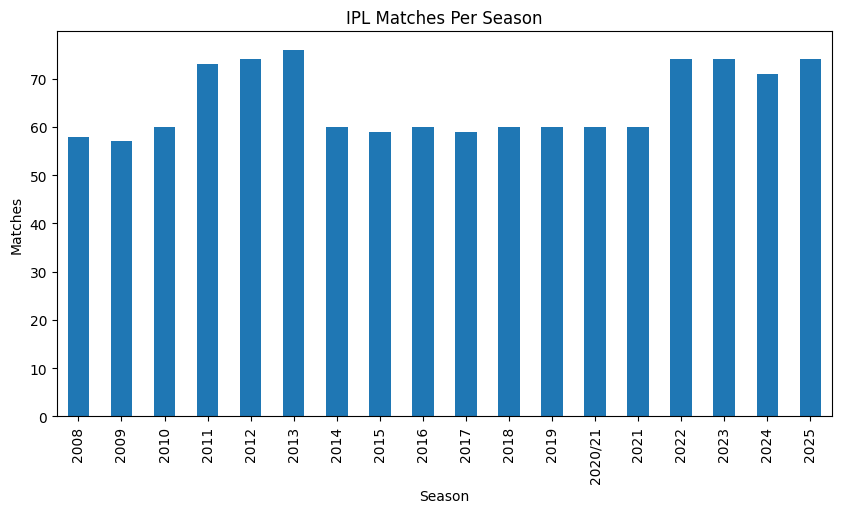

In [40]:
plt.figure(figsize=(10,5))

matches_per_season.plot(kind='bar')

plt.title("IPL Matches Per Season")

plt.xlabel("Season")

plt.ylabel("Matches")

plt.show()

In [41]:
team_wins = matches['match_winner'].value_counts()

print(team_wins.head(10))

match_winner
Mumbai Indians                 153
Chennai Super Kings            142
Kolkata Knight Riders          135
Royal Challengers Bangalore    133
Sunrisers Hyderabad            125
Punjab Kings                   123
Delhi Capitals                 121
Rajasthan Royals               116
Gujarat Titans                  37
Lucknow Super Giants            30
Name: count, dtype: int64


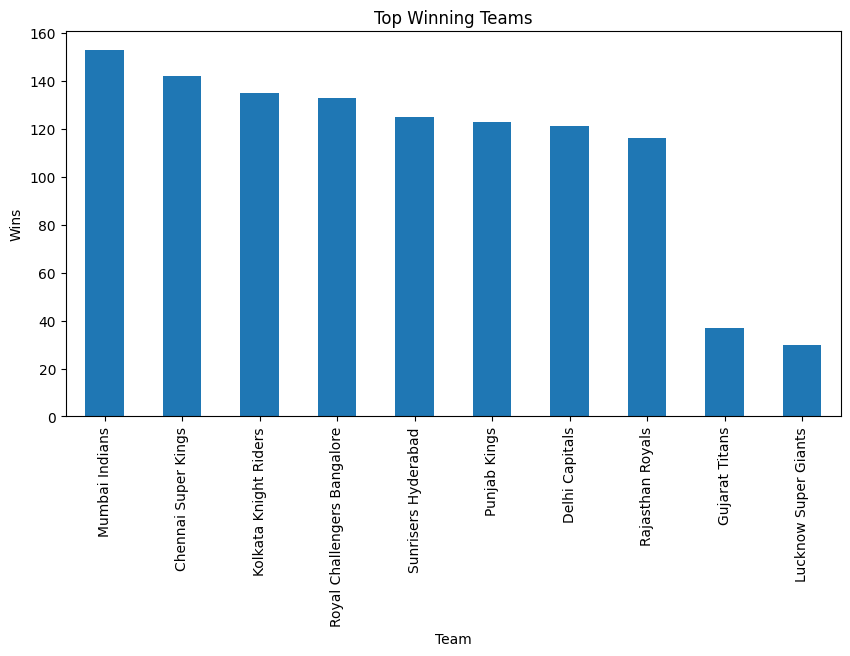

In [42]:
plt.figure(figsize=(10,5))

team_wins.head(10).plot(kind='bar')

plt.title("Top Winning Teams")

plt.xlabel("Team")

plt.ylabel("Wins")

plt.show()

In [43]:
toss_wins = matches['toss_winner'].value_counts()

print(toss_wins.head(10))

toss_winner
Mumbai Indians                 151
Sunrisers Hyderabad            138
Delhi Capitals                 138
Kolkata Knight Riders          128
Chennai Super Kings            128
Royal Challengers Bangalore    128
Rajasthan Royals               127
Punjab Kings                   121
Gujarat Titans                  29
Lucknow Super Giants            24
Name: count, dtype: int64


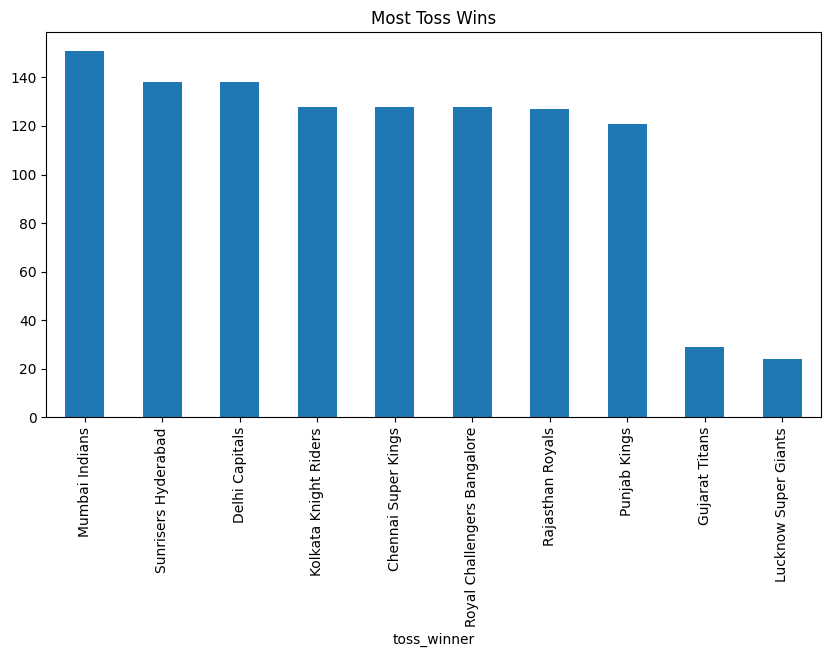

In [44]:
plt.figure(figsize=(10,5))

toss_wins.head(10).plot(kind='bar')

plt.title("Most Toss Wins")

plt.show()

In [45]:
print(matches['toss_decision'].value_counts())

toss_decision
field    764
bat      404
Name: count, dtype: int64


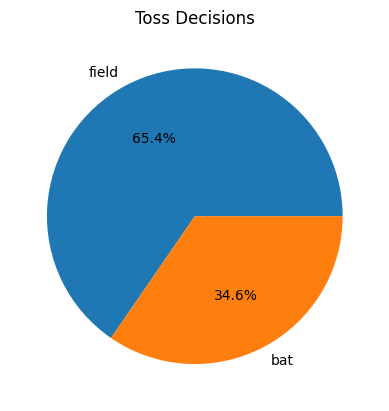

In [46]:
matches['toss_decision'].value_counts().plot(
kind='pie',
autopct='%1.1f%%'
)

plt.ylabel("")

plt.title("Toss Decisions")

plt.show()

In [47]:
venue_matches = matches['venue'].value_counts()

print(venue_matches.head(10))

venue
Eden Gardens                                  77
Wankhede Stadium                              73
M Chinnaswamy Stadium                         65
Feroz Shah Kotla                              60
Wankhede Stadium, Mumbai                      52
Rajiv Gandhi International Stadium, Uppal     49
MA Chidambaram Stadium, Chepauk               48
Sawai Mansingh Stadium                        47
Dubai International Cricket Stadium           46
Punjab Cricket Association Stadium, Mohali    35
Name: count, dtype: int64


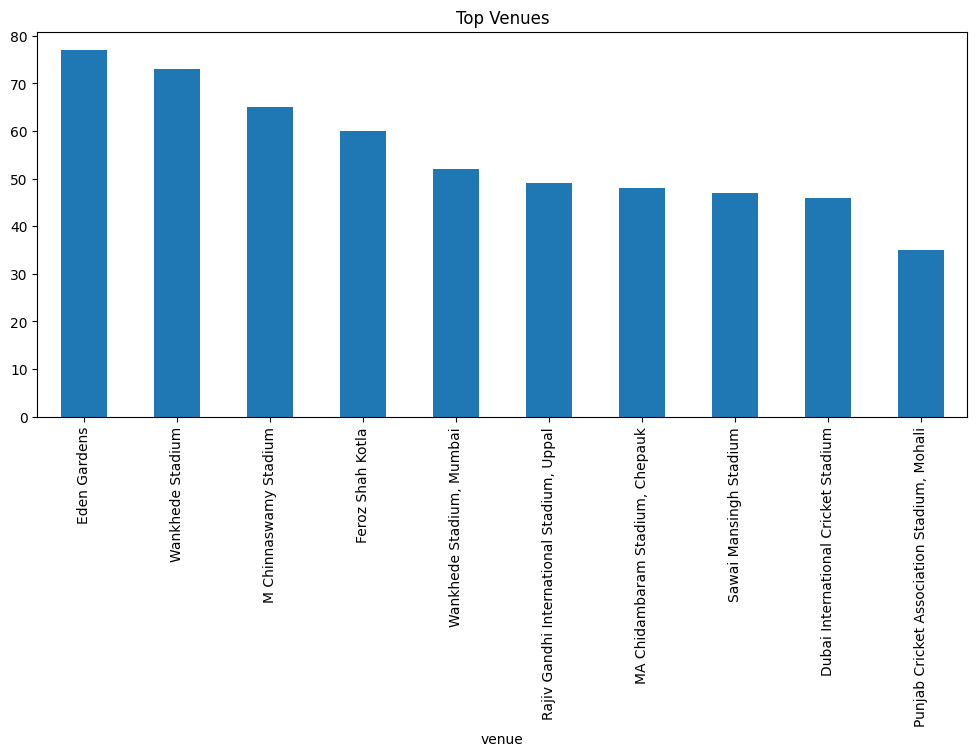

In [48]:
plt.figure(figsize=(12,5))

venue_matches.head(10).plot(kind='bar')

plt.title("Top Venues")

plt.show()

In [49]:
city_matches = matches['city'].value_counts()

print(city_matches.head(10))

city
Mumbai        180
Kolkata       100
Delhi          97
Chennai        91
Hyderabad      83
Bangalore      65
Jaipur         64
Chandigarh     61
Pune           51
Ahmedabad      45
Name: count, dtype: int64


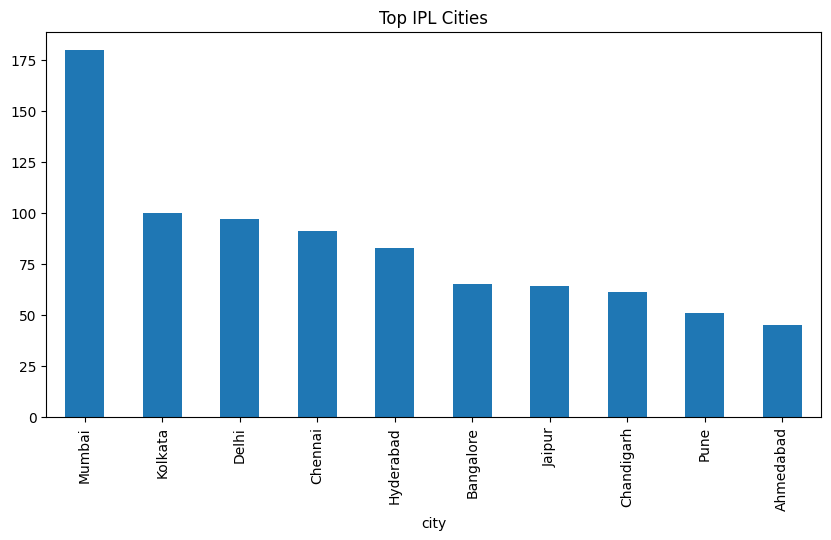

In [50]:
plt.figure(figsize=(10,5))

city_matches.head(10).plot(kind='bar')

plt.title("Top IPL Cities")

plt.show()

In [51]:
print(matches['player_of_match'].value_counts().head(10))

player_of_match
245.0     25
1.0       22
25.0      21
332.0     19
38.0      18
12.0      18
65.0      17
5.0       16
348.0     16
1437.0    16
Name: count, dtype: int64


In [52]:
print(matches['result'].value_counts())

result
win          1146
tie            15
no result       8
Name: count, dtype: int64


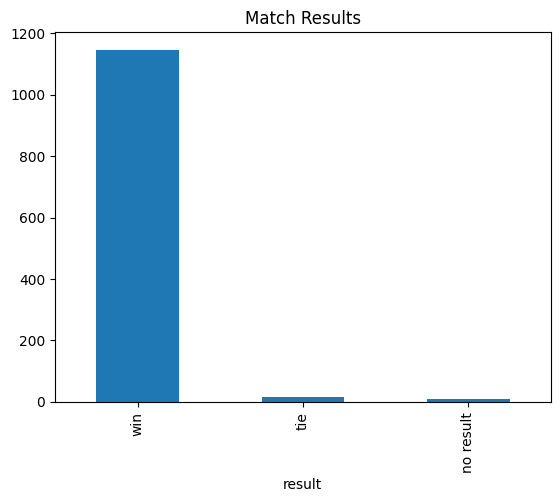

In [53]:
matches['result'].value_counts().plot(
kind='bar'
)

plt.title("Match Results")

plt.show()

In [54]:
print("========== IPL SUMMARY ==========")

print("Matches :", matches.shape[0])

print("Seasons :", matches['season'].nunique())

print("Teams :", teams_played.nunique())

print("Top Team :", matches['match_winner'].mode()[0])

print("Top Venue :", matches['venue'].mode()[0])

print("Top City :", matches['city'].mode()[0])

========== IPL SUMMARY ==========
Matches : 1169
Seasons : 18
Teams : 14
Top Team : Mumbai Indians
Top Venue : Eden Gardens
Top City : Mumbai
